# 08. PyTorch Paper Replicating

The goal of machine learning paper replicating is to turn a ML research paper into code

In this notebook we're going to be replicating the Vision Transformer (ViT) paper: https://arxiv.org/abs/2010.11929



In [ ]:
import torch
import torchvision
import torchaudio

In [ ]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device


## 1. Get Data
Since we're continuing on with FoodVision Mini, let's download the pizza, steak and sushi image dataset we've been using.

To do so we can use the download_data() function from helper_functions.py that we created in 07. PyTorch Experiment Tracking section 1.

In [ ]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

In [ ]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

## 2. Create Datasets and DataLoaders
Now we've got some data, let's now turn it into DataLoader's.

To do so we can use the create_dataloaders() function in data_setup.py.

First, we'll create a transform to prepare our images.

### 2.1 Prepare transforms for images

In [ ]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")


### 2.2 Turn images into DataLoaders

The ViT paper states the use of a batch size of 4096 which is 128x the size of the batch size we've been using (32).

However, we're going to stick with a batch size of 32.

In [ ]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

len(train_dataloader), len(test_dataloader), len(class_names)

### 2.3 Visualize a single image

In [ ]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

In [ ]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

## 3. Replicating the ViT paper: an overview
Before we write any more code, let's discuss what we're doing.

We'd like to replicate the ViT paper for our own problem, FoodVision Mini.

So our model inputs are: images of pizza, steak and sushi.

And our ideal model outputs are: predicted labels of pizza, steak or sushi.

No different to what we've been doing throughout the previous sections.

The question is: how do we go from our inputs to the desired outputs?

### 3.1 Inputs and outputs, layers and blocks
ViT is a deep learning neural network architecture.

Any neural network architecture is generally comprised of layers.

And a collection of layers is often referred to as a block.

And stacking many blocks together is what gives us the whole architecture.

A layer takes an input (say an image tensor), performs some kind of function on it (for example what's in the layer's forward() method) and then returns an output.

So if a single layer takes an input and gives an output, then a collection of layers or a block also takes an input and gives an output.

Let's make this concrete:

* Layer - takes an input, performs a function on it, returns an output.
* Block - a collection of layers, takes an input, performs a series of functions on it, returns an output.
* Architecture (or model) - a collection of blocks, takes an input, performs a series of functions on it, returns an output.

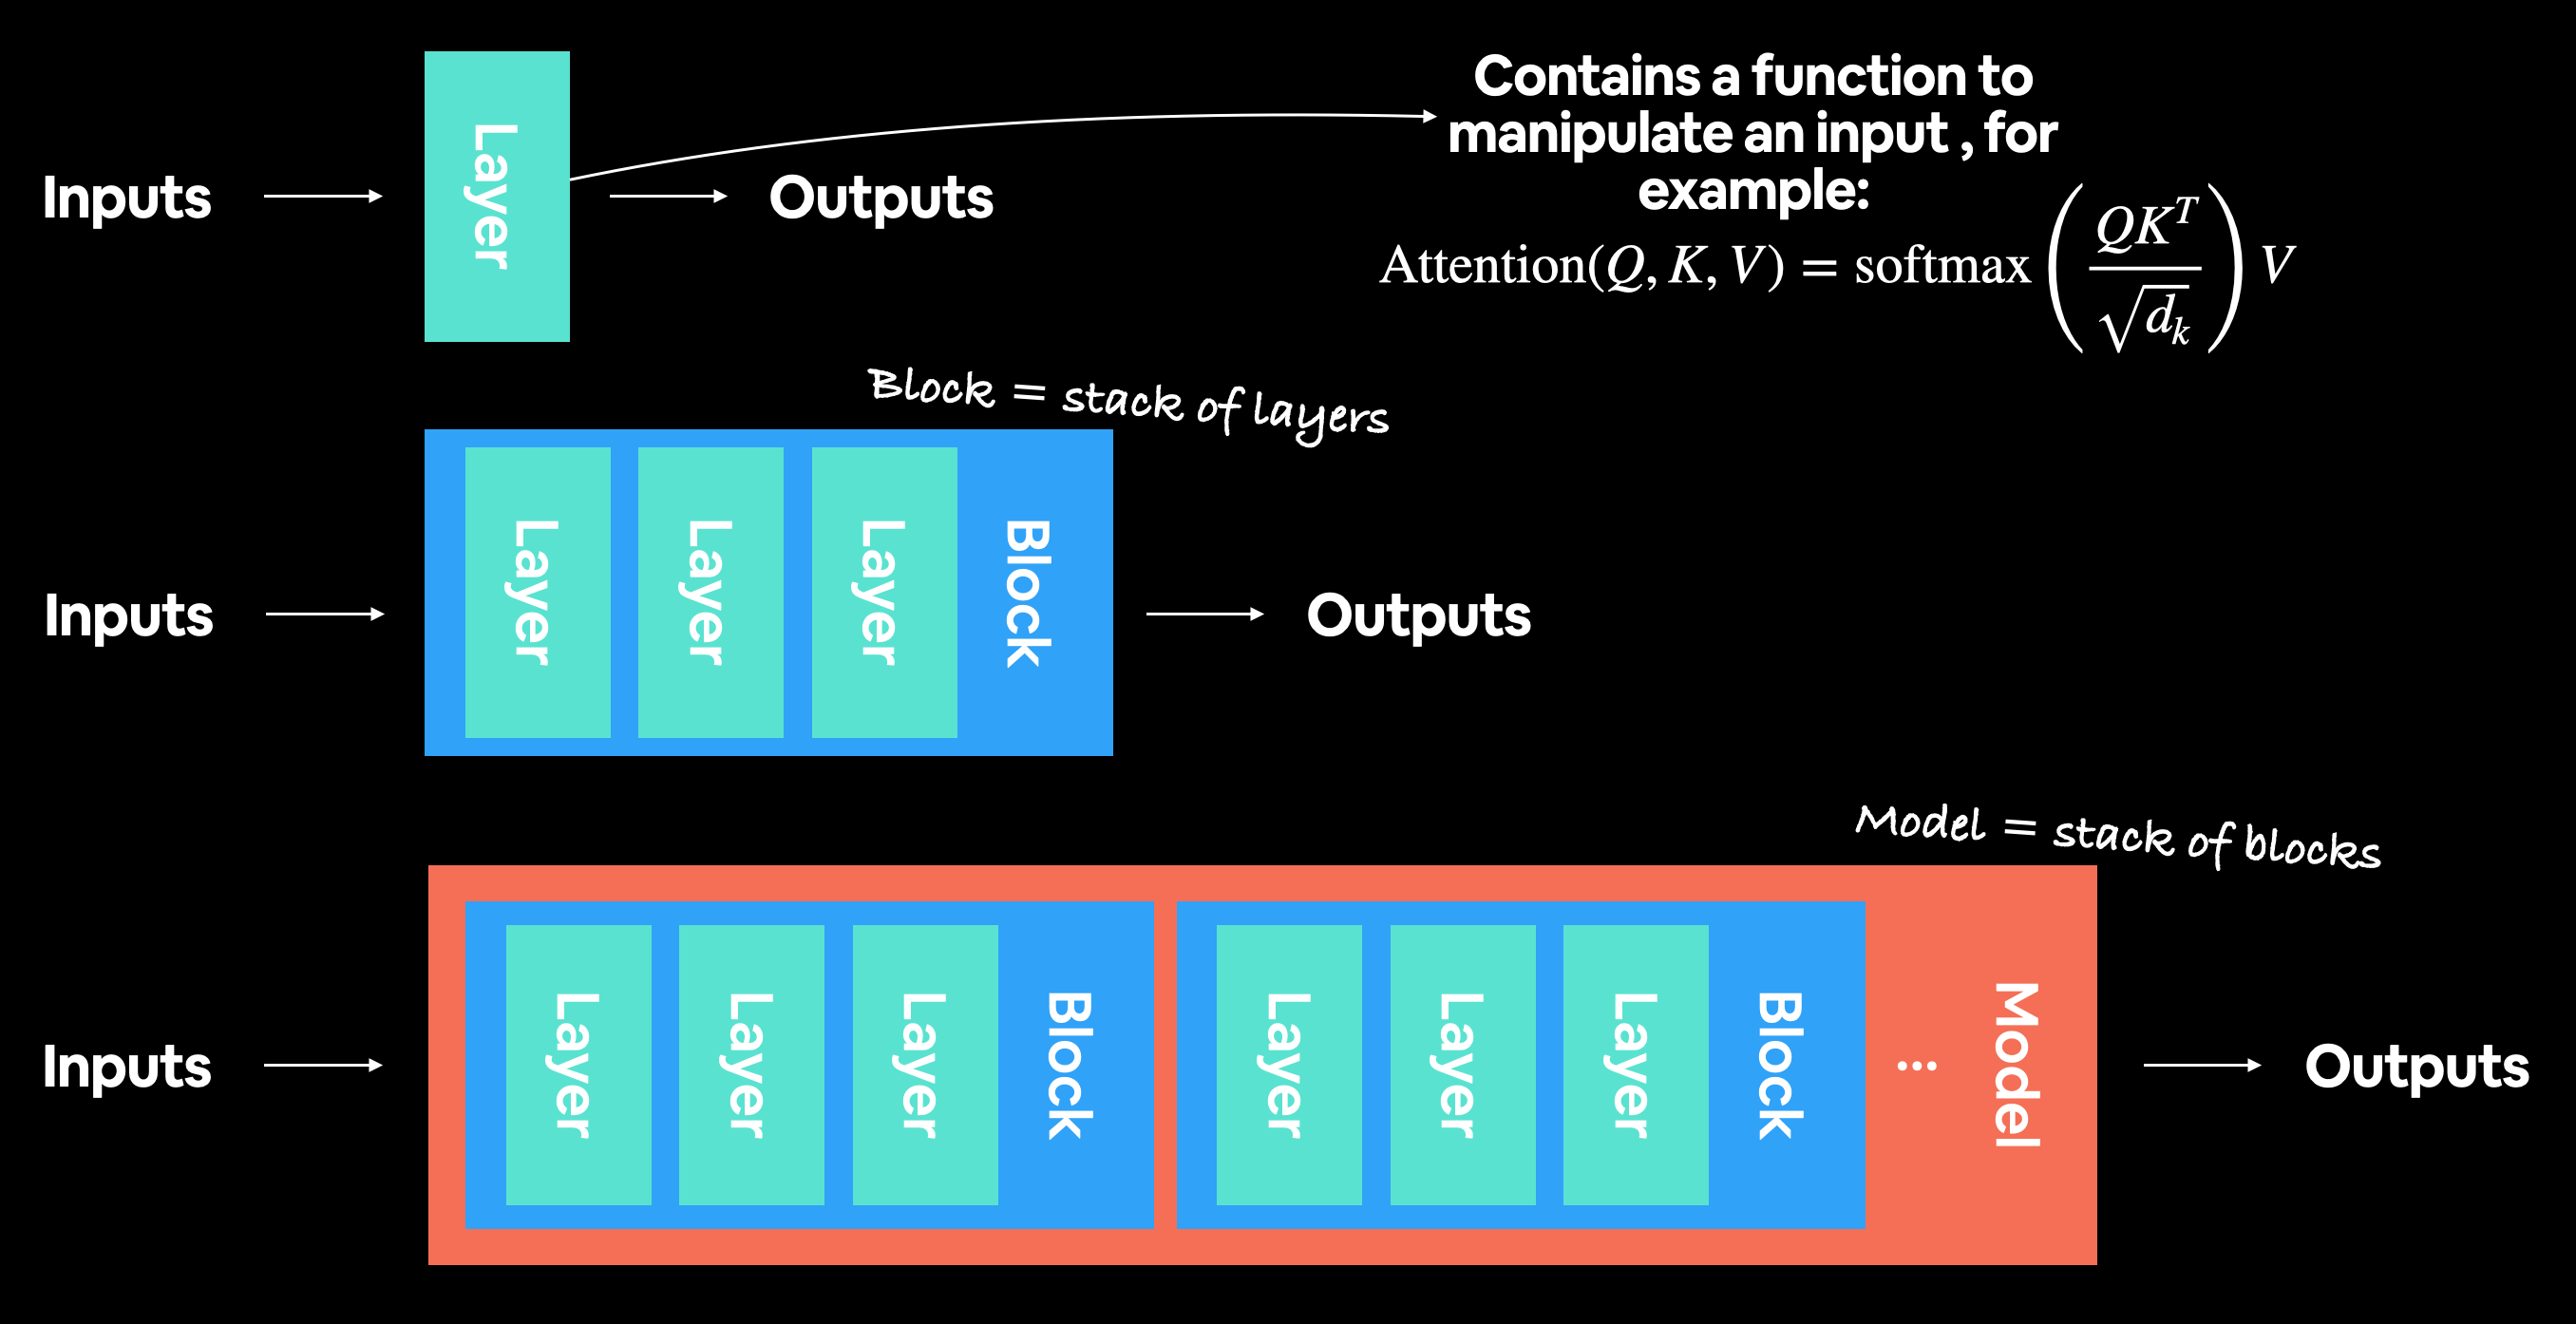

### 3.2 Getting specific: What's ViT made of?

1. Figure 1 - This gives an overview of the model in a graphical sense, you could almost recreate the architecture with this figure alone.
2. Four equations in section 3.1 - These equations give a little bit more of a mathematical grounding to the coloured blocks in Figure 1.
3. Table 1 - This table shows the various hyperparameter settings (such as number of layers and number of hidden units) for different ViT model variants. We'll be focused on the smallest version, ViT-Base.

### 3.2.1 Exploring Figure 1
1. Layers - takes an input, performs an operation or function on the input, produces an output.
2. Blocks - a collection of layers, which in turn also takes an input and produces an output.

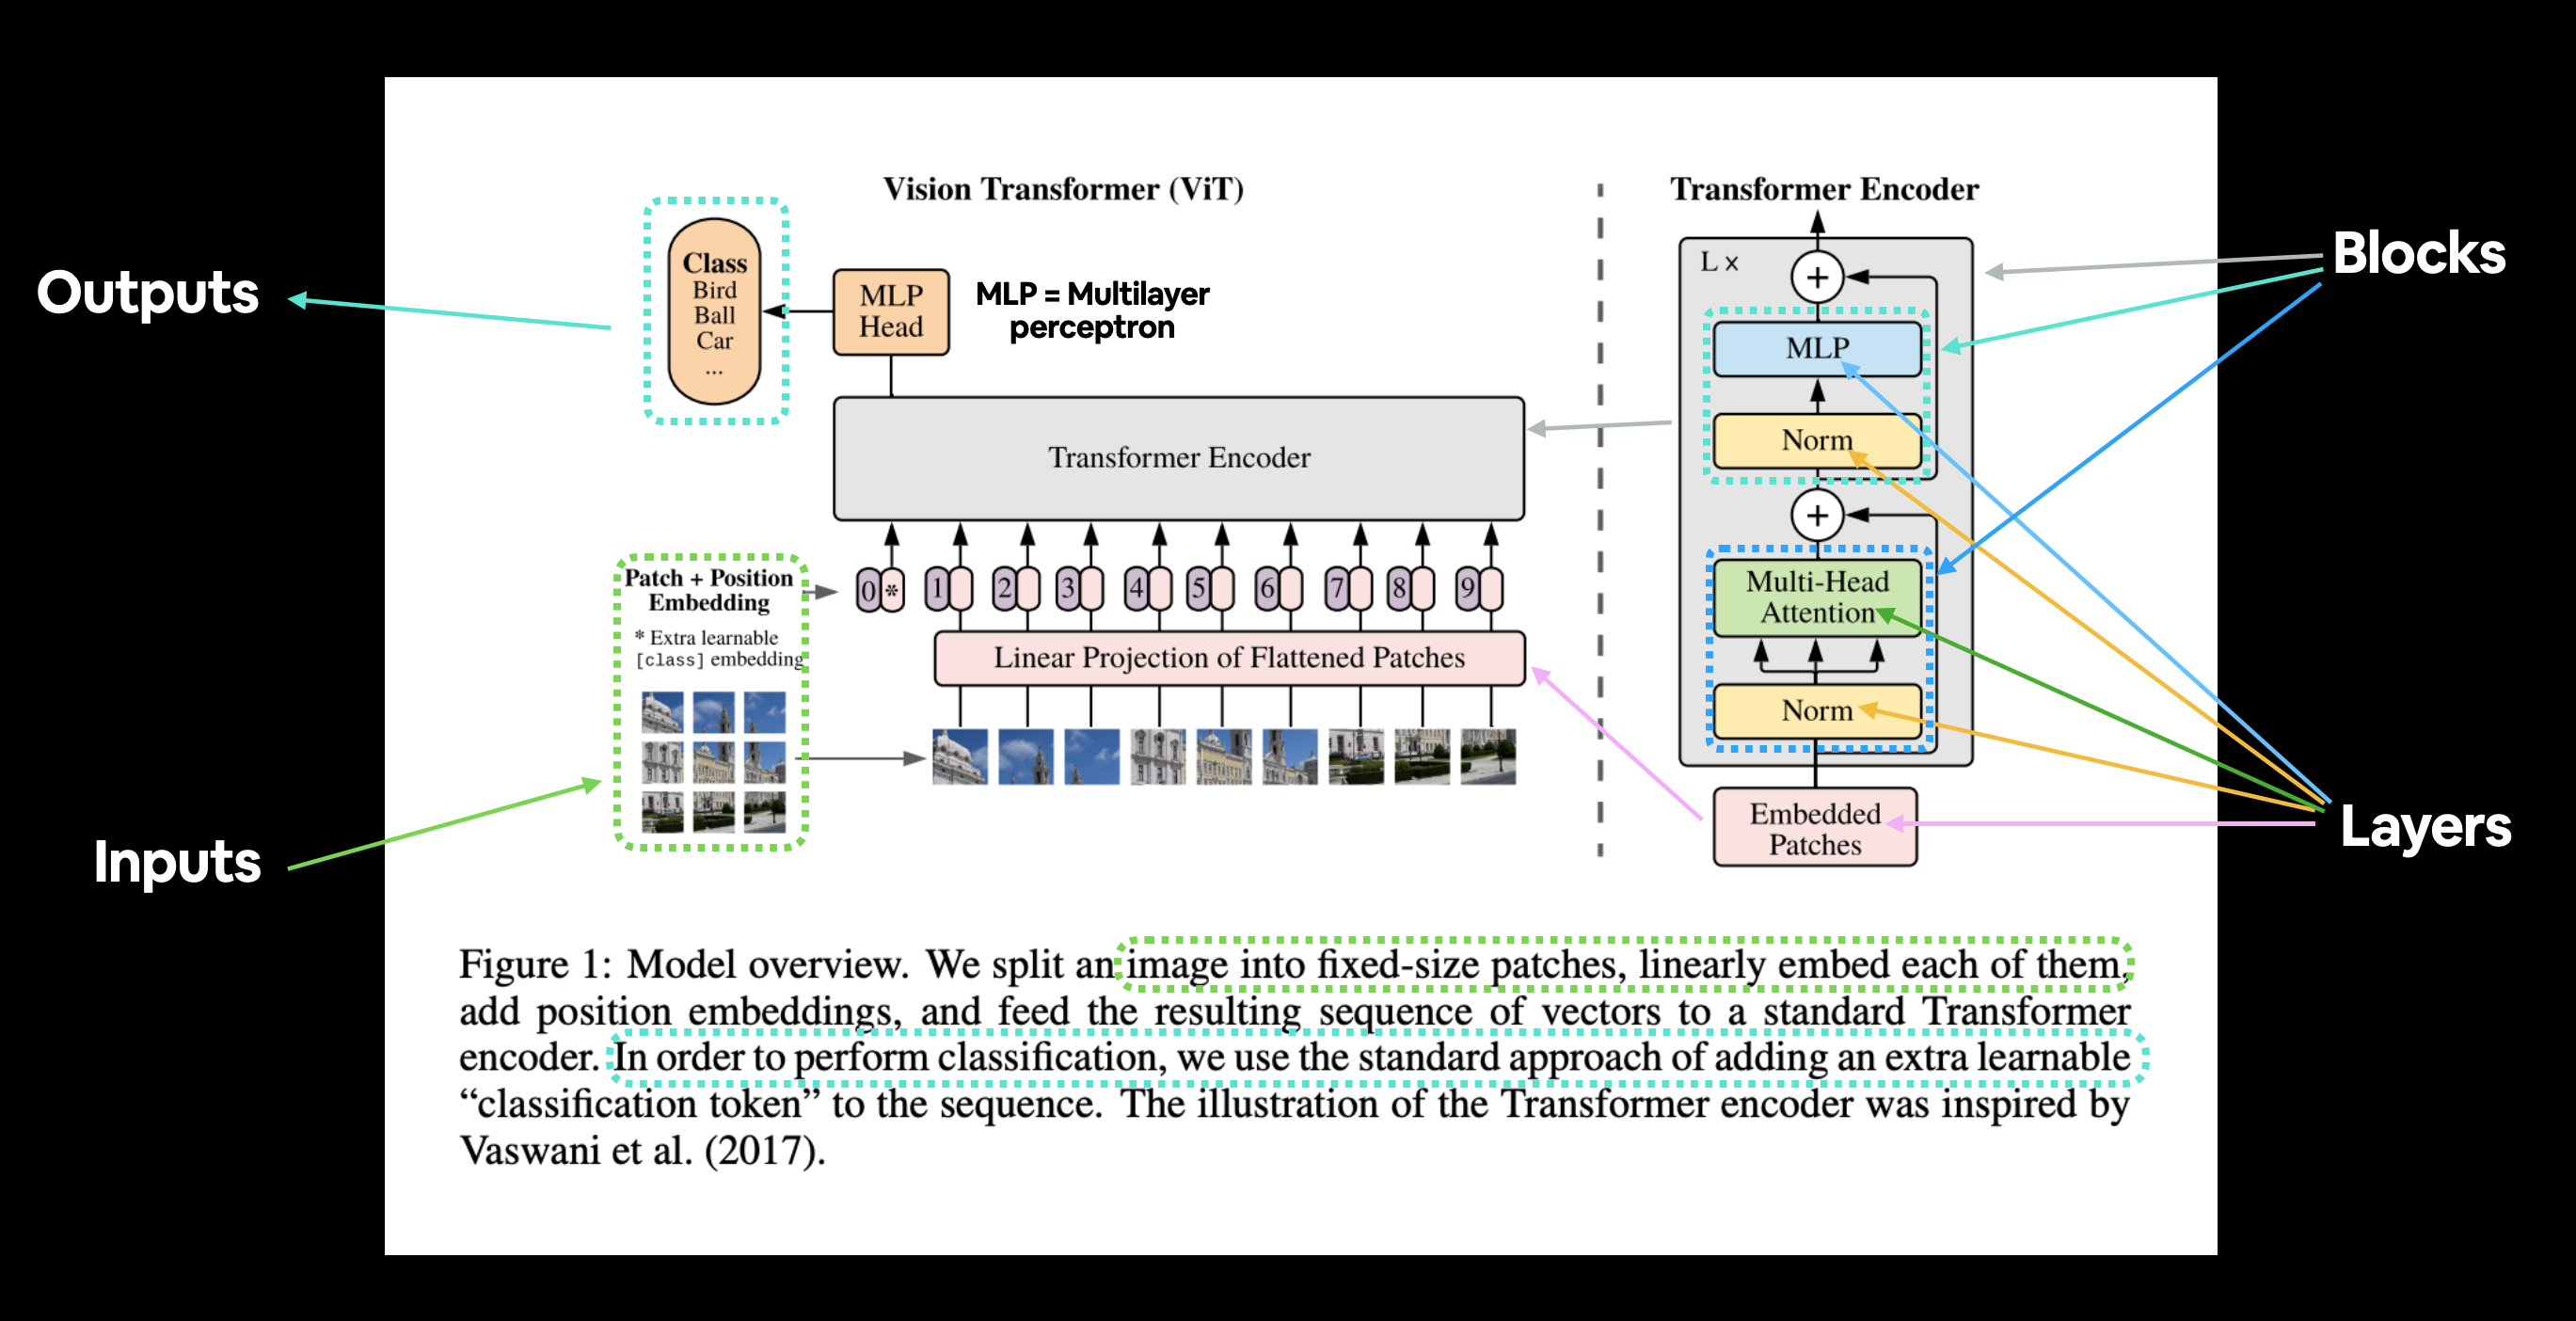

The ViT architecture is comprised of several stages:

* Patch + Position Embedding (inputs) - Turns the input image into a sequence of image patches and adds a position number to specify in what order the patch comes in.
* Linear projection of flattened patches (Embedded Patches) - The image patches get turned into an embedding, the benefit of using an **embedding** rather than just the image values is that an ***embedding is a learnable representation*** (typically in the form of a vector) of the image that can improve with training.
* Norm - This is short for "Layer Normalization" or "LayerNorm", a technique for regularizing (reducing overfitting) a neural network, you can use LayerNorm via the PyTorch layer torch.nn.LayerNorm().
* Multi-Head Attention - This is a Multi-Headed Self-Attention layer or "MSA" for short. You can create an MSA layer via the PyTorch layer torch.nn.MultiheadAttention().
* MLP (or Multilayer perceptron) - A MLP can often refer to any collection of feedforward layers (or in PyTorch's case, a collection of layers with a forward() method). In the ViT Paper, the authors refer to the MLP as "MLP block" and it contains two torch.nn.Linear() layers with a torch.nn.GELU() non-linearity activation in between them (section 3.1) and a torch.nn.Dropout() layer after each (Appendix B.1).
* Transformer Encoder - The Transformer Encoder, is a collection of the layers listed above. There are two skip connections inside the Transformer encoder (the "+" symbols) meaning the layer's inputs are fed directly to immediate layers as well as subsequent layers. The overall ViT architecture is comprised of a number of Transformer encoders stacked on top of eachother.
* MLP Head - This is the output layer of the architecture, it converts the learned features of an input to a class output. Since we're working on image classification, you could also call this the "classifier head". The structure of the MLP Head is similar to the MLP block.

### 3.2.2 Exploring the Four Equations
The next main part(s) of the ViT paper we're going to look at are the four equations in section 3.1.

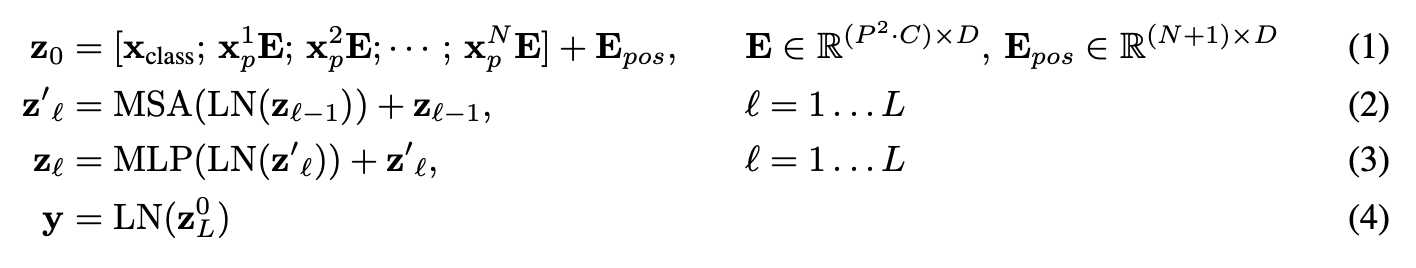

four mathematical equations from the vision transformer machine learning paper

These four equations represent the math behind the four major parts of the ViT architecture.

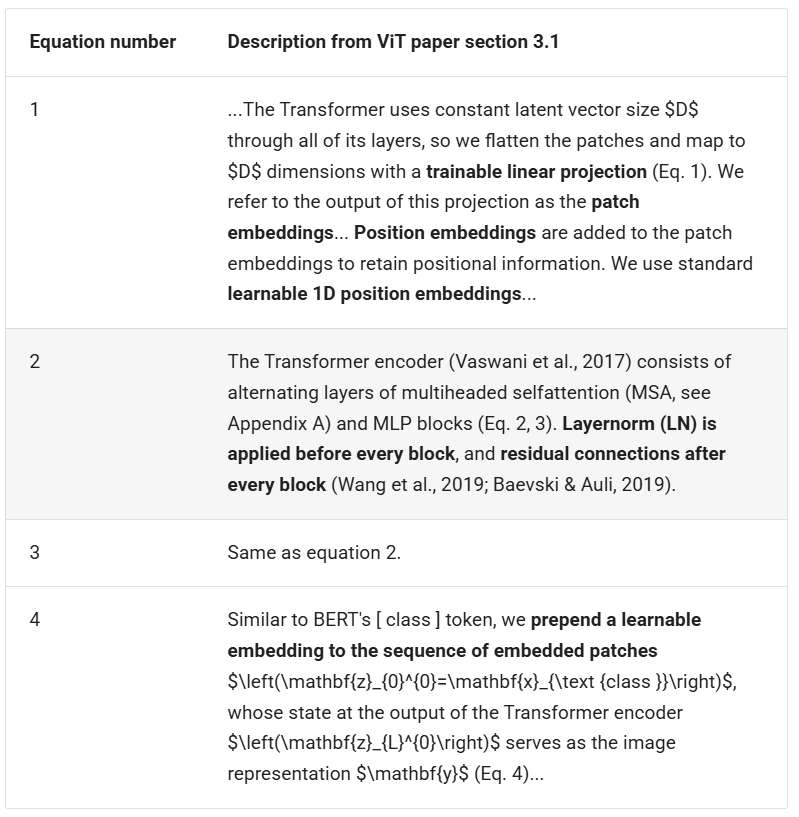

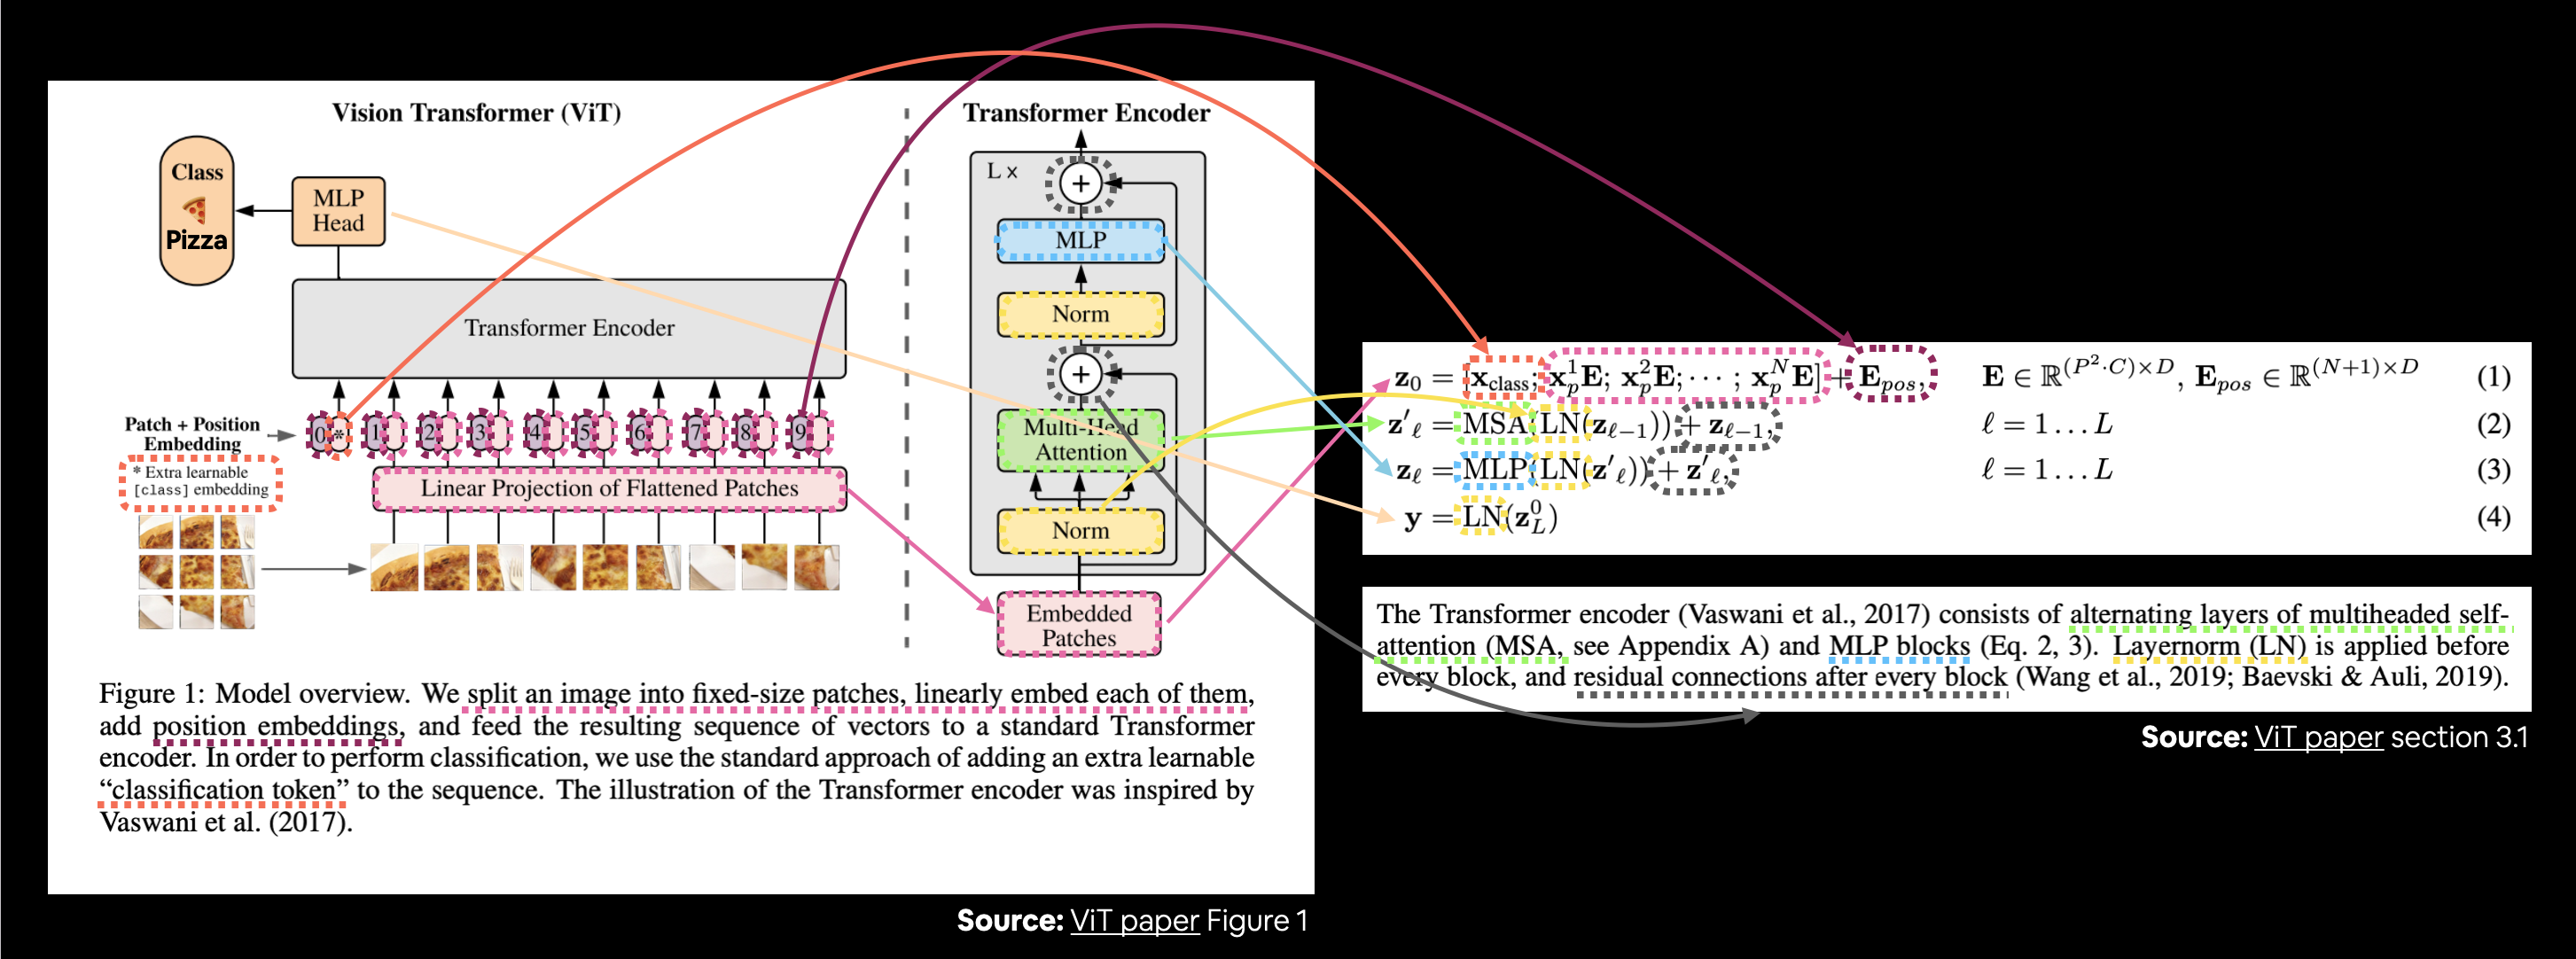

### 3.2.3 The final piece of the ViT architecture puzzle we'll focus on (for now) is Table 1.

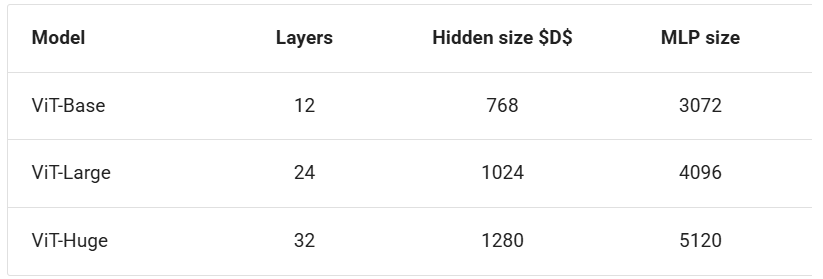

This table showcasing the various hyperparameters of each of the ViT architectures.

You can see the numbers gradually increase from ViT-Base to ViT-Huge.

We're going to focus on replicating ViT-Base (start small and scale up when necessary) but we'll be writing code that could easily scale up to the larger variants.

Breaking the hyperparameters down:

**Layers** - How many Transformer Encoder blocks are there? (each of these will contain a MSA block and MLP block)

**Hidden size $D$** - This is the embedding dimension throughout the architecture, this will be the size of the vector that our image gets turned into when it gets patched and embedded. Generally, the larger the embedding dimension, the more information can be captured, the better results. However, a larger embedding comes at the cost of more computation.

**MLP size** - What are the number of hidden units in the MLP layers?

**Heads** - How many heads are there in the Multi-Head Attention layers?

**Params** - What are the total number of parameters of the model? Generally, more parameters leads to better performance but at the cost of more computation. You'll notice even ViT-Base has far more parameters than any other model we've used so far.

- We'll use these values as the hyperparameter settings for our ViT architecture.

## 4. Equation 1: Split data into patches and creating the class, position, and patch embedding

Layers = input -> function -> output

What's the input shape?

What's the output shape?

### 4.1

* Input Shape: (224,224,3) HxWxColor Channels
* Output Shape: \mathbb{R}^{N \times\left(P^{2} \cdot C\right)}$

- H = Height
- W = Width
- C = Color Channels
- P = Patch Size
- N = number of patches = height x width / P^2
- D = Constant latent vector size = embedding dimension




In [ ]:
# Create example values
height = 224
width = 224
color_channels = 3
patch_size = 16

# Calculate the number of patches
number_of_patches = (height * width) / (patch_size ** 2)
number_of_patches

In [ ]:
# Input shape
embedding_layer_input_shape = (height, width, color_channels)
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

embedding_layer_input_shape, embedding_layer_output_shape

print(f"Input Shape: {embedding_layer_input_shape}")
print(f"Output Shape: {embedding_layer_output_shape}")

### 4.2 Turning a single image into patches



In [ ]:
# View a single image
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

In [ ]:
image.shape

In [ ]:
# Get the top row of the image
image_permuted = image.permute(1,2,0) # Convert image to have color channels last

# Index to plot the top row of pixels
patch_size = 16
plt.figure(figsize=(patch_size,patch_size))
plt.imshow(image_permuted[:patch_size, :, :])

In [ ]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size, # one column for each patch
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Iterate through number of patches in the top row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :]); # keep height index constant, alter the width index
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [ ]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

### 4.3 Creating image patches and turning them into patch embeddings

We can create thee patches and image patch embedings in a single step using 'torch.nn.Conv2d()' and set the kernel size and stride parameters to 'patch_size'

In [ ]:
# Create conv2d layer to turn image into patches of learnable feature maps (embeddings)

from torch import nn

# Set the pathc size
patch_size = 16

# Create conv2d
conv2d = nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)
conv2d

In [ ]:
# View single image
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

In [ ]:
# Pass iamge through the convolutional layer
image_out_of_conv = conv2d(image.unsqueeze(dim=0))
image_out_of_conv.shape

We've passed a single image to our conv2d layer, its shape is:

torch.Size([1, 768, 14, 14]) # [batch_size, embedding_dim, feature_map_height, feature_map_width]

In [ ]:
image_out_of_conv.requires_grad

In [ ]:
# plot random conv feature maps
import random
random_indexes = random.sample(range(0,758), k=5)
print(f"Showing random conv feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12,12))

# Plot random image feature maps
for i, index in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, index, :, :] # input on the output tensor
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy()) # Remove batch dimension
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    axs[i].set_title(f"Conv Feature Map {index}")

In [ ]:
# Get a single feature map in tensor form
single_conv_feature_map = image_out_of_conv[:, 0, :, :]
single_conv_feature_map, single_conv_feature_map.requires_grad

### 4.4 Flatten the patch embedding with torch.nn.Flatten()

In [ ]:
print(f"{image_out_of_conv.shape} -> (batch_size, embedding_dim, feature_map_height, feature_map_width)")

In [ ]:
from torch import nn
flatten_layer = nn.Flatten(start_dim=2, end_dim=3)

flatten_layer(image_out_of_conv).shape

In [ ]:
# Put everything together
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)
print(f"Original image shape: {image.shape}")

# Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension
print(f"Image feature map (patches) shape: {image_out_of_conv.shape}")

# Flatten the feature maps
image_out_of_conv_flattened = flatten_layer(image_out_of_conv)
print(f"Flattened feature maps shape: {image_out_of_conv_flattened.shape}")

In [ ]:
# Rearrange the output of flattened layer
image_out_of_conv_flattened_permuted = image_out_of_conv_flattened.permute(0,2,1)
print(f"Flattened feature maps shape: {image_out_of_conv_flattened_permuted.shape}")

In [ ]:
single_flattened_feature_map = image_out_of_conv_flattened_permuted[:, :, 0]

# Plot
plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened Feature Map shape {single_flattened_feature_map.shape}")
plt.axis(False)

### 4.5 Turning the ViT patch embedding layer into a PyTorch module

We want this to module to do a few things:
1. Create a class called 'PatchEmbedding'
2. Initialize with appropriate hyperparameters, such as channels, embedding dimension, patch size
3. Create a layer to turn an image into embedding patches using conv2d
4. Create a layer to flatten the feature maps of the output of the layer in 3.
5. Define a forward() method to take an input and pass it through the layers created in 3 and 4.
6. Make sure the output shape reflects the required output shape of the patch embedding

In [ ]:
from torch import nn
# 1. Create a class called 'PatchEmbedding'
class PatchEmbedding(nn.Module):

# 2. Initialize with appropriate hyperparameters, such as channels, embedding dimension, patch size
  def __init__(self,
               in_channels: int = 3,
               embedding_dim: int = 768, # From ViT-Base
               patch_size: int = 16):
    super().__init__()

    # 3. Create layer to turn image into embedded patches
    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size, # Added stride to match kernel_size
                             padding=0)

    # 4. Create a layer to flatten feature map output of conv2d
    self.flatten = nn.Flatten(start_dim=2, # Corrected from nn.flatten to nn.Flatten
                              end_dim=3)
    self.patch_size = patch_size # Stored patch_size as an attribute

  # 5. Define forward method
  def forward(self, x):
    # check if inputs are correct shape
    image_resolution = x.shape[-1]
    assert image_resolution % self.patch_size == 0, f"Input image must be divisible by patch size, image shape: {image_resolution}, patch size: {self.patch_size}" # Corrected image.resolution to image_resolution and & to %

    # Perform pass
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)

    # 6. Make sure returned embedding dimensions are in the right order
    return x_flattened.permute(0,2,1)

In [ ]:
set_seeds()

# Create an instance of patch embedding layer
patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

# Pass a single image through
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
print(f"Output patch embedding shape: {patch_embedded_image.shape}")

In [ ]:
# Create random input sizes
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250) # will error because image size is incompatible with patch_size

# # Get a summary of the input and outputs of PatchEmbedding (uncomment for full output)
# summary(PatchEmbedding(),
#         input_size=random_input_image, # try swapping this for "random_input_image_error"
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"])

### 4.6 Creating the class token embedding
Okay we've made the image patch embedding, time to get to work on the class token embedding.

In [ ]:
patch_embedded_image

In [ ]:
# Get the batch size and embedding dimension
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

# Create the class token embedding as a learnable parameter that shares the same size as the embedding dimension (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), # [batch_size, number_of_tokens, embedding_dimension]
                           requires_grad=True) # make sure the embedding is learnable

# Show the first 10 examples of the class_token
print(class_token[:, :, :10])

# Print the class_token shape
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

In [ ]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

**Analogy**

- Think of the class token like a “notepad” sitting at the front of the line of patches.

- Each patch tells it what’s important as it passes through the layers.

- By the end, the notepad has written down a summary of the whole image, which the classifier then reads.
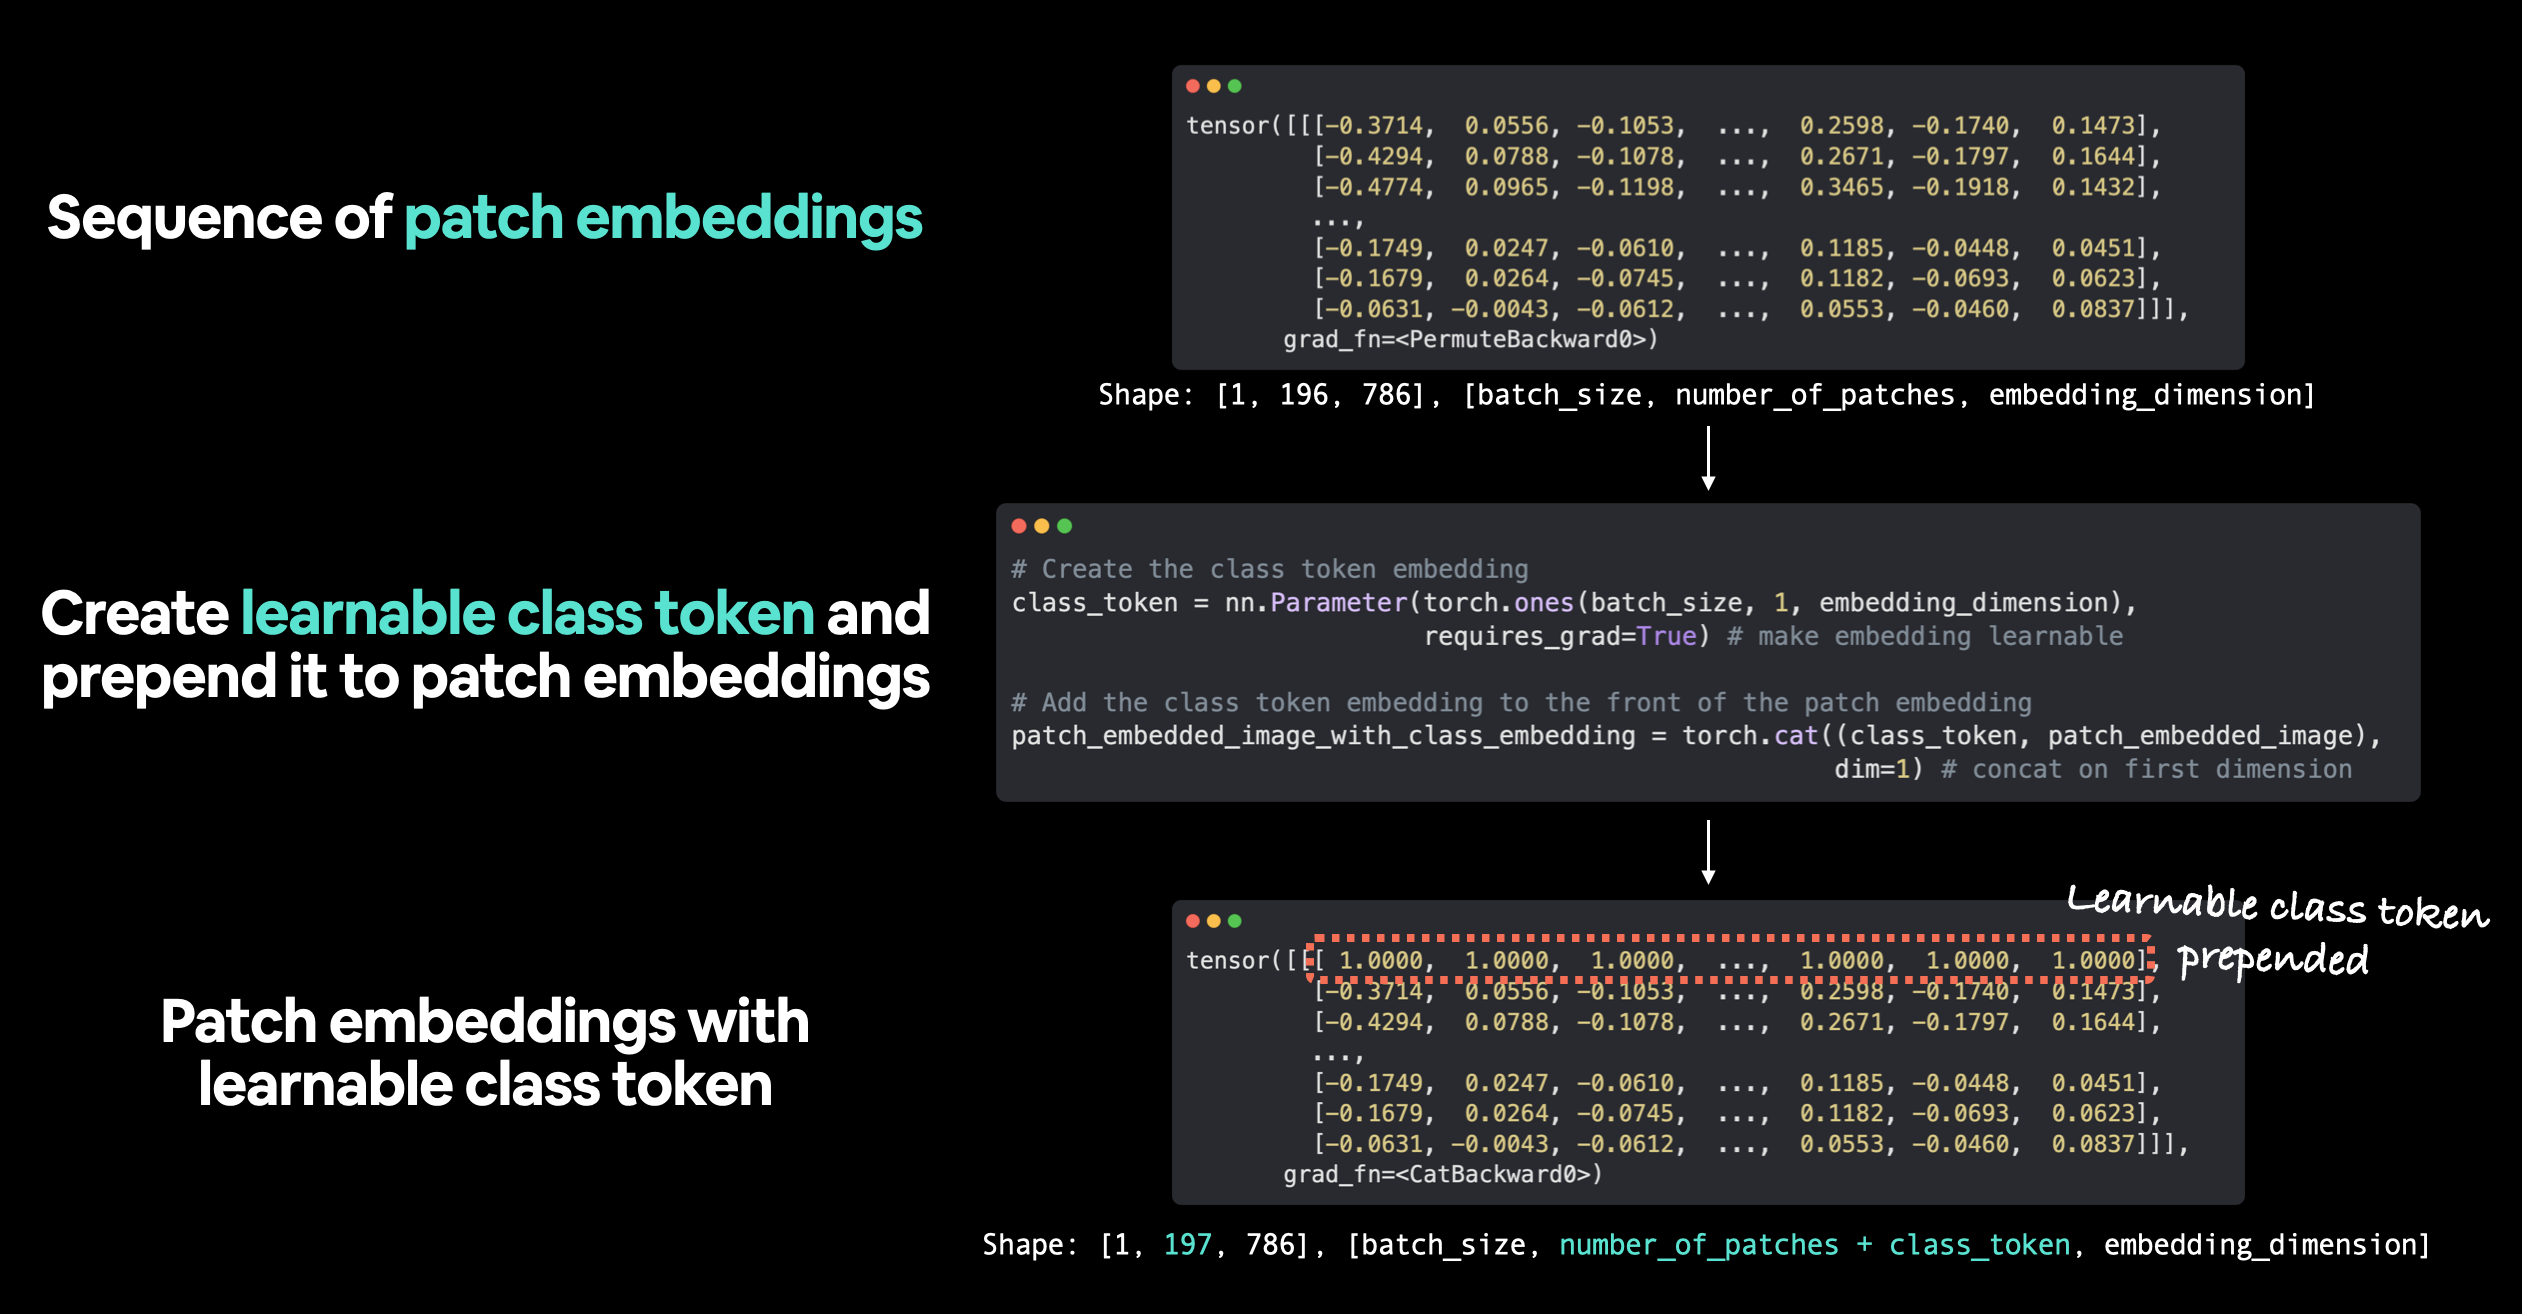

### 4.7 Creating the position embedding

In [ ]:
# View the sequence of patch embeddings with the prepended class embedding
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape

In [ ]:
# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[-1]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# Show the first 10 sequences and 10 position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

In [ ]:
# Add the position embedding to the patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

### 4.8 Putting it all together: from image to embedding

We can do so by:

Setting the patch size (we'll use 16 as it's widely used throughout the paper and for ViT-Base).
Getting a single image, printing its shape and storing its height and width.
Adding a batch dimension to the single image so it's compatible with our PatchEmbedding layer.
Creating a PatchEmbedding layer (the one we made in section 4.5) with a patch_size=16 and embedding_dim=768 (from Table 1 for ViT-Base).
Passing the single image through the PatchEmbedding layer in 4 to create a sequence of patch embeddings.
Creating a class token embedding like in section 4.6.
Prepending the class token embedding to the patch embeddings created in step 5.
Creating a position embedding like in section 4.7.
Adding the position embedding to the class token and patch embeddings created in step 7.
We'll also make sure to set the random seeds with set_seeds() and print out the shapes of different tensors along the way.

### 4.8 Putting it all together: from image to embedding

We can do so by:

1. Setting the patch size (we'll use 16 as it's widely used throughout the paper and for ViT-Base).
2. Getting a single image, printing its shape and storing its height and width.
3. Adding a batch dimension to the single image so it's compatible with our PatchEmbedding layer.
4. Creating a PatchEmbedding layer (the one we made in section 4.5) with a patch_size=16 and embedding_dim=768 (from Table 1 for ViT-Base).
5. Passing the single image through the PatchEmbedding layer in 4 to create a sequence of patch embeddings.
6. Creating a class token embedding like in section 4.6.
7. Prepending the class token embedding to the patch embeddings created in step 5.
8. Creating a position embedding like in section 4.7.
9. Adding the position embedding to the class token and patch embeddings created in step 7.

We'll also make sure to set the random seeds with set_seeds() and print out the shapes of different tensors along the way.

In [ ]:
set_seeds()

# 1. Set patch size
patch_size = 16

# 2. Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# 6. Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

# 8. Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# 9. Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

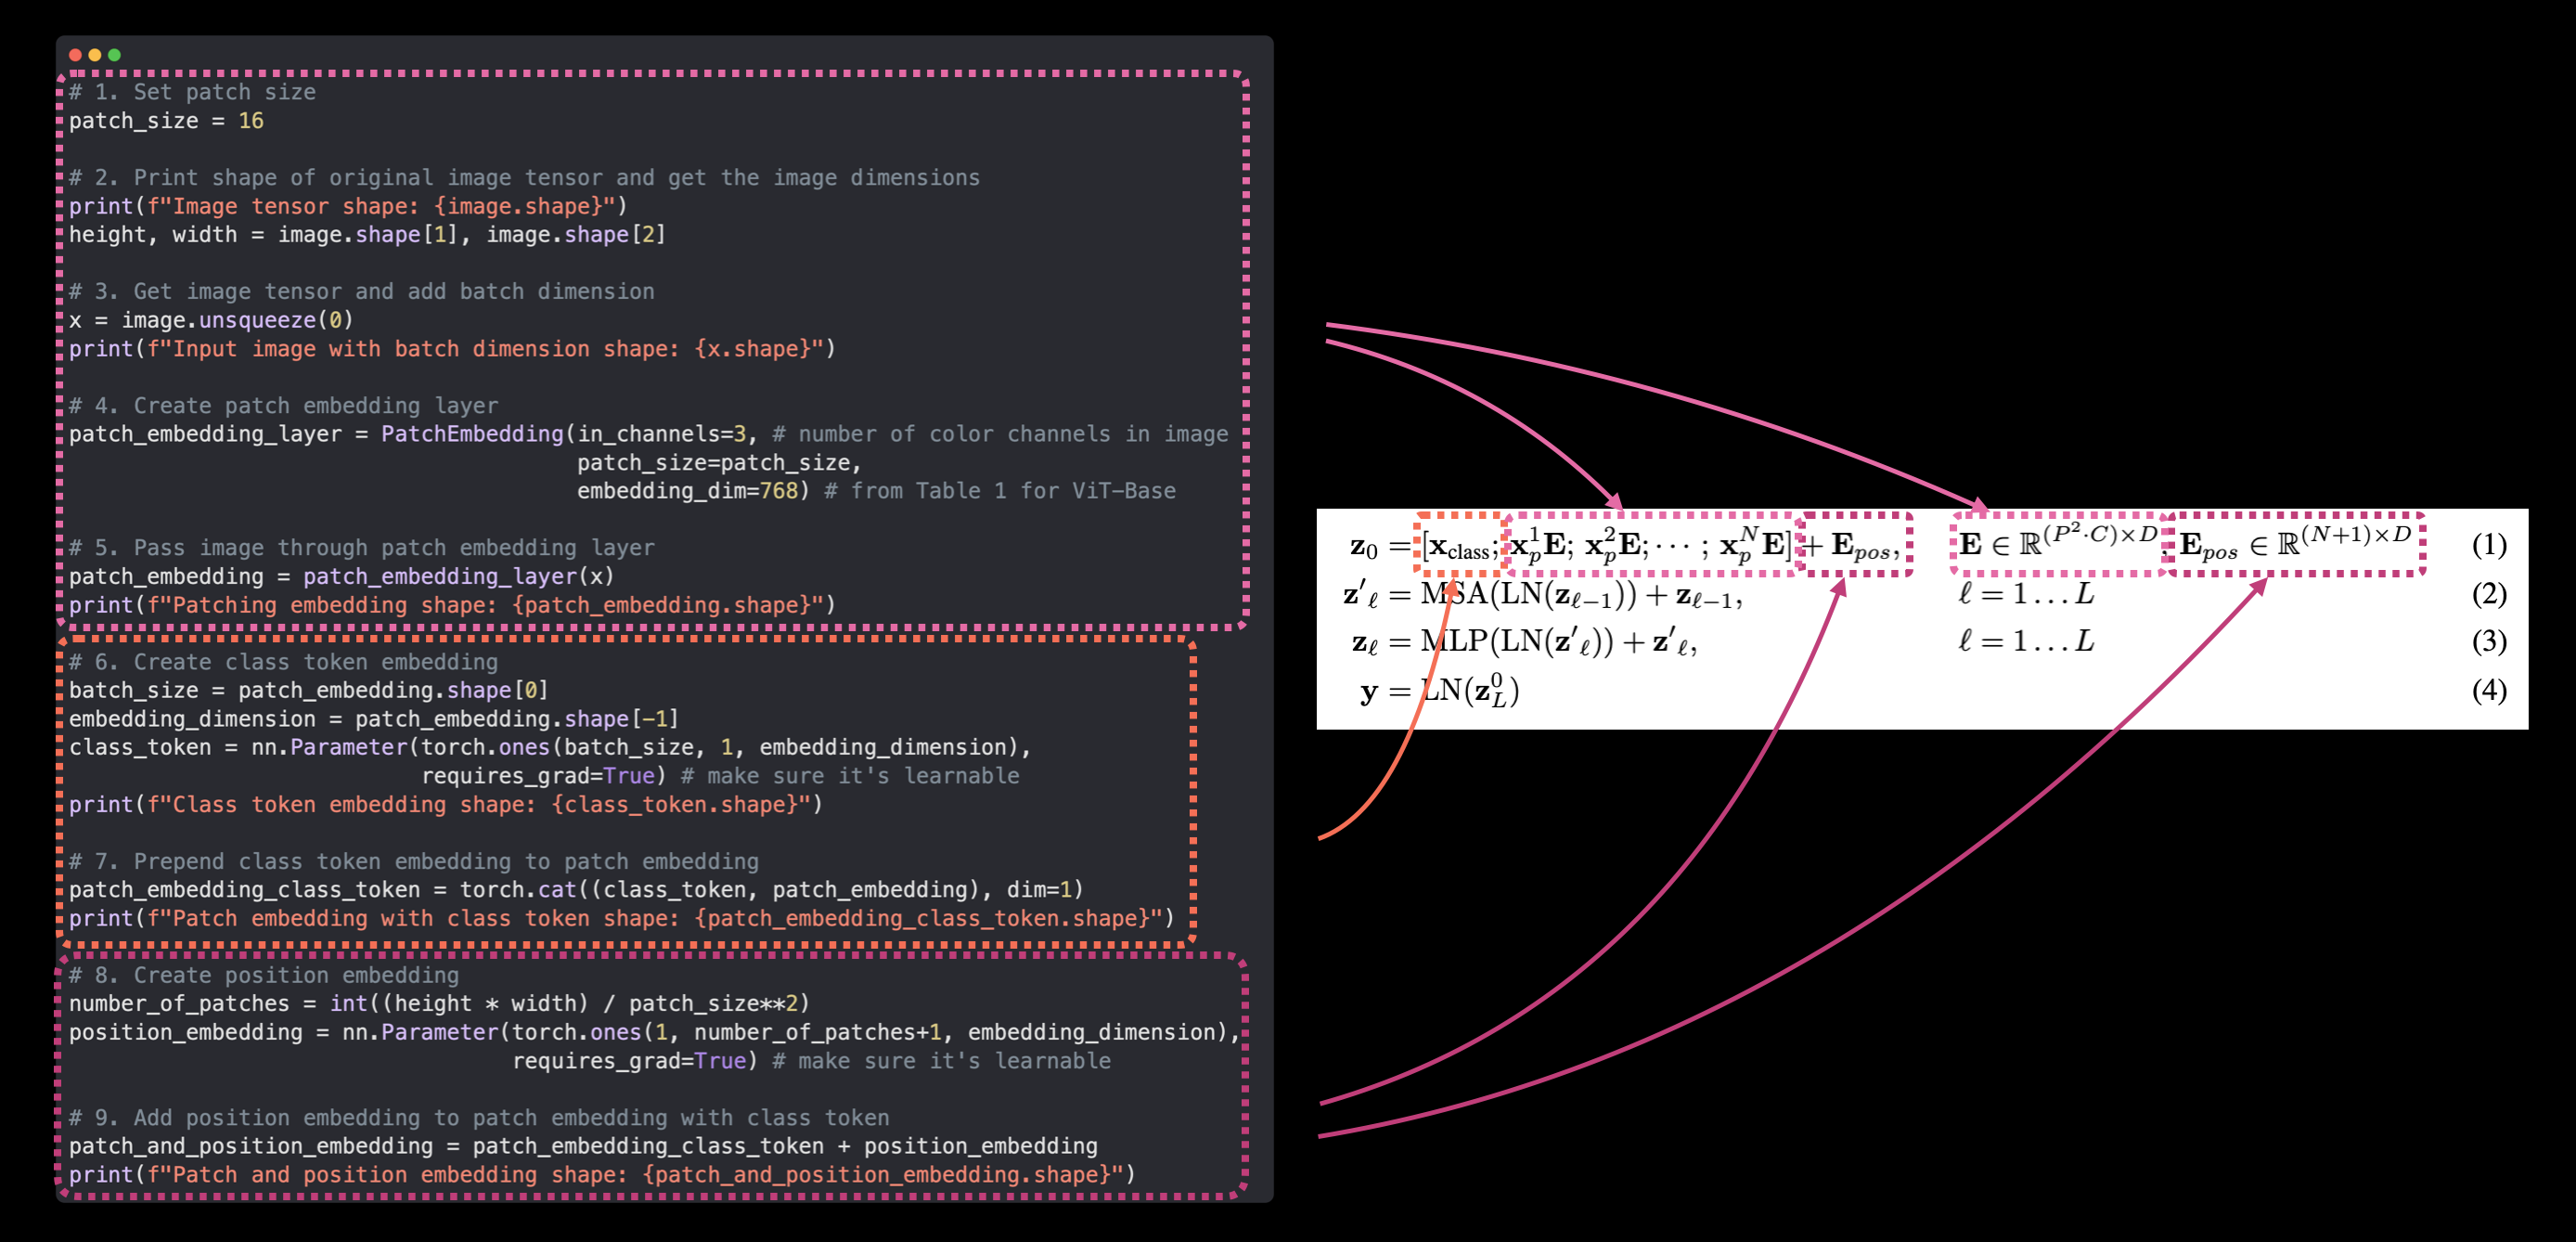

## 5. Equation 2: Multi-Head Attention (MSA)
**MSA: Which part of a sequence should pay the most attention to itself?**

  **In our case, we have a series of embedded image patches, which patch significantly relates to another patch.**


The first being equation 2 and the second being equation 3.

Recall equation 2 states:
 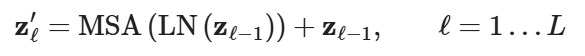


### 5.1 The LayerNorm (LN) layer
Layer Normalization (torch.nn.LayerNorm() or Norm or LayerNorm or LN) normalizes an input over the last dimension.

You can find the formal definition of torch.nn.LayerNorm() in the PyTorch documentation.

PyTorch's torch.nn.LayerNorm()'s main parameter is normalized_shape which we can set to be equal to the dimension size we'd like to normalize over (in our case it'll be $D$ or 768 for ViT-Base).

What does it do?

- Layer Normalization helps improve training time and model generalization (ability to adapt to unseen data).

I like to think of any kind of normalization as "getting the data into a similar format" or "getting data samples into a similar distribution".

Imagine trying to walk up (or down) a set of stairs all with differing heights and lengths.

It'd take some adjustment on each step right?

And what you learn for each step wouldn't necessarily help with the next one since they all differ, increasing the time it takes you to navigate the stairs.

Normalization (including Layer Normalization) is the equivalent of making all the stairs the same height and length except the stairs are your data samples.

So just like you can walk up (or down) stairs with similar heights and lengths much easier than those with unequal heights and widths, neural networks can optimize over data samples with similar distributions (similar mean and standard-deviations) easier than those with varying distributions.

**Let’s imagine we’re in a big team project meeting:**

🔹 Tokens

Think of tokens as the people in the meeting.

Each person has their own notes (embedding vector).

In text: each token = word/subword.

In images: each token = an image patch.

🔹 Patch Embeddings

For an image, patches are like bringing in different photos of the project.

Each photo is cropped into pieces (patches) and handed to different team members.

Now everyone has a chunk of the picture they’re responsible for.

🔹 Multi-Head Self-Attention (MSA)

The meeting starts. Each person (token) looks around the table and asks:

“Who else in this room is relevant to me?”

They pay more attention to the people (tokens) who matter for their part of the project.

Different “heads” = different perspectives:

One head might focus on grammar (who’s the subject).

Another might focus on meaning (dog ↔ animal).

In images, one head might look for edges, another for colors, another for shapes.

At the end, each person has updated notes that mix in insights from others.

🔹 LayerNorm

After the discussion, people’s notes are a mess — some are too long, some too short.

LayerNorm is like a meeting moderator who says:

“Okay everyone, clean up your notes. Keep them in the same format, same scale, so we can compare them easily.”

This keeps the meeting organized and consistent.

🔹 Feedforward Layer

Once the discussion is done and notes are normalized, each person spends a moment privately refining their notes (passing through a small neural net).

This adds more depth before the next meeting round.

🔹 Transformer Stack

The project doesn’t finish in one meeting. You need many meetings (layers).

Each meeting builds richer understanding:

First meeting: “Oh, we’re talking about dogs.”

Later meetings: “This is a picture of a golden retriever playing fetch in the park.”

✅ In short:

Tokens = people in a meeting

Patch embeddings = chunks of data assigned to people

MSA = group discussion, everyone shares info

LayerNorm = moderator cleaning things up

Feedforward = personal reflection

Stacked layers = many meetings, deeper understanding

In [ ]:
class MultiHeadSelfAttentionBlock(nn.Module):
    '''Creates a multi-head self attention block'''
    def __init__(self,
                 embedding_dim = 768,
                 num_heads = 12,
                 attn_dropout = 0):
      super().__init__()
      # Create the norm layer (LN)
      self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

      # Create MSA Layer
      self.multi_head_attention = nn.MultiheadAttention(embed_dim = embedding_dim,
                                                        num_heads = num_heads,
                                                        dropout = attn_dropout,
                                                        batch_first=True)
    def forward(self, x):
      x = self.layer_norm(x)
      attn_output, _ = self.multi_head_attention(query=x,
                                                 key=x,
                                                 value=x,
                                                 need_weights=False)
      return attn_output

In [ ]:
# Creating an instance of MSA Block
multihead_self_attention_block = MultiHeadSelfAttentionBlock(embedding_dim=768,
                                                             num_heads=12,
                                                             attn_dropout=0)

# Pass the patch and position image embedding sequence through MSA block
msa_output = multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape of MSA block: {msa_output.shape}")

## 6. Equation 3: Multilayer Perceptron (MLP block)

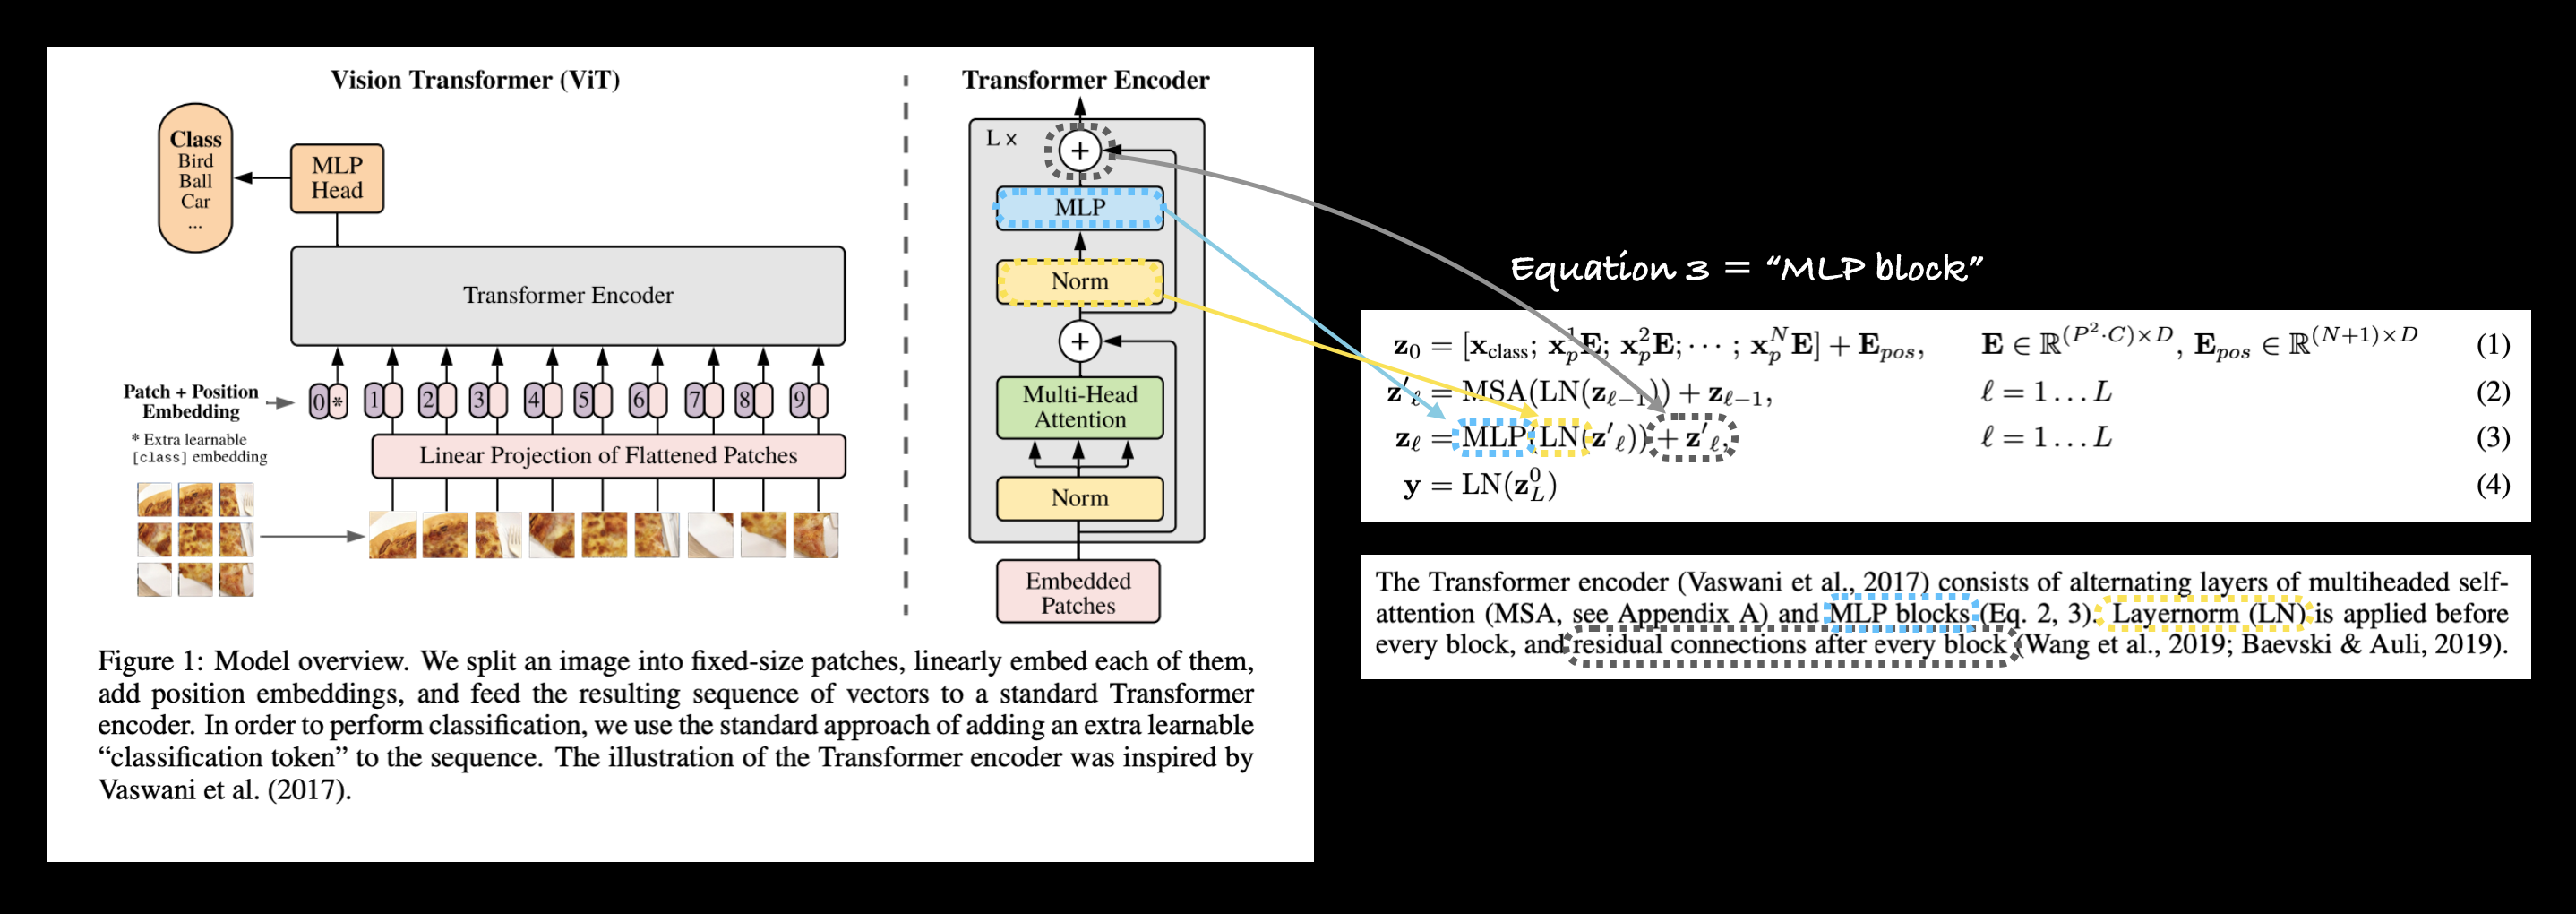

🔹 Analogy

Continuing the “meeting” analogy we used earlier:

MSA = everyone talking and sharing information.

MLP = each person goes back to their desk and writes a more detailed, refined note based on what they learned in the discussion.

It adds depth and non-linearity, letting the model represent more complex patterns.

In [ ]:
class MLPBlock(nn.Module):
  def __init__(self,
               embedding_dim = 768,
               mlp_size=3072,# number of hidden units
               dropout=0.1):
    super().__init__()

    # Create norm layer
    self.layer_norm = nn.LayerNorm(embedding_dim)

    # Create the MLP
    self.mlp = nn.Sequential(
        nn.Linear(in_features=embedding_dim, out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size, out_features=embedding_dim),
        nn.Dropout(p=dropout)
    )
  def forward(self, x):
    x = self.layer_norm(x)
    x = self.mlp(x)
    return x

In [ ]:
# Create an instance of MLPBlock
mlp_block = MLPBlock(embedding_dim=768,
                     mlp_size=3072,
                     dropout=0.1)

# Pass output the MSABlock through MLPBlock
patched_image_through_mlp_block = mlp_block(msa_output)

# Print the output shape
print(f"Input shape: {msa_output.shape}")
print(f"Output shape: {patched_image_through_mlp_block.shape}")

In [ ]:
msa_output

## 7. Create the Transformer Encoder

The transformer encoder is a combination of alternating MLP and MSA Blocks.

- Encoder = Turn a sequence into a learnable representation
- Decoder = Go from learned representation back to some sort of sequence
- Residual connections = add a layer(s) input to its subsequent output, this enables the creation of deeper networks (prevents weights from getting too small)

Or in pseudocode:

x_input -> MSA_block -> [MSA_block_output + x_input] -> MLP_block -> [MLP_block_output + MSA_block_output + x_input] -> ...

In [ ]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               embedding_dim=768, # Hidden size D
               num_heads=12,
               mlp_size=3072,
               mlp_dropout=0.1,
               attn_dropout=0,):
    super().__init__()

    # Create MSA Block
    self.msa_block = MultiHeadSelfAttentionBlock(embedding_dim=embedding_dim,
                         num_heads=num_heads,
                         attn_dropout=attn_dropout)

    # Create MLP Block
    self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                              mlp_size=mlp_size,
                              dropout=mlp_dropout)

  def forward(self, x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x
    return x

In [ ]:
# Create instance
transformer_encoder_block = TransformerEncoderBlock()

# Get a summary
summary(model=transformer_encoder_block,
        input_size=(1, 197, 768),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

### 7.1 Create a Transformer Encoder layer with build-in PyTorch layers

PyTorch has implemented ready-to-use encoder layers

In [ ]:
# Create the same as above with torch.nn.TransformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768,
                                                    nhead=12,
                                                    dim_feedforward=3072,
                                                    dropout=0.1,
                                                    activation='gelu',
                                                    batch_first=True,
                                                    norm_first=True)

torch_transformer_encoder_layer

In [ ]:
# Get a summary
summary(model=torch_transformer_encoder_layer,
        input_size=(1, 197, 768),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

**Why spend all this time recreating the Transformer Encoder when we would have just done it with a single PyTorch function? Practice and Understanding.**

## 8. Putting it all together to create ViT

In [ ]:
# 1. Create a ViT class that inherits from nn.Module
class ViT(nn.Module):
  """Creates a Vision Transformer architecture with ViT-Base hyperparameters by default."""
  # 2. Initialize the class with hyperparameters from Table 1 and Table 3
  def __init__(self,
                img_size:int=224, # Training resolution from Table 3 in ViT paper
                in_channels:int=3, # Number of channels in input image
                patch_size:int=16, # Patch size
                num_transformer_layers:int=12, # Layers from Table 1 for ViT-Base
                embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                num_heads:int=12, # Heads from Table 1 for ViT-Base
                attn_dropout:float=0, # Dropout for attention projection
                mlp_dropout:float=0.1, # Dropout for dense/MLP layers
                embedding_dropout:float=0.1, # Dropout for patch and position embeddings
                num_classes:int=1000): # Default for ImageNet but can customize this
      super().__init__() # don't forget the super().__init__()!

      # 3. Make the image size is divisible by the patch size
      assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

      # 4. Calculate number of patches (height * width/patch^2)
      self.num_patches = (img_size * img_size) // patch_size**2

      # 5. Create learnable class embedding (needs to go at front of sequence of patch embeddings)
      self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                          requires_grad=True)

      # 6. Create learnable position embedding
      self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                              requires_grad=True)

      # 7. Create embedding dropout value
      self.embedding_dropout = nn.Dropout(p=embedding_dropout)

      # 8. Create patch embedding layer
      self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                            patch_size=patch_size,
                                            embedding_dim=embedding_dim)

      # 9. Create Transformer Encoder blocks (we can stack Transformer Encoder blocks using nn.Sequential())
      # Note: The "*" means "all"
      self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                          num_heads=num_heads,
                                                                          mlp_size=mlp_size,
                                                                          mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])

      # 10. Create classifier head
      self.classifier = nn.Sequential(
          nn.LayerNorm(normalized_shape=embedding_dim),
          nn.Linear(in_features=embedding_dim,
                    out_features=num_classes)
      )

  # 11. Create a forward() method
  def forward(self, x):

      # 12. Get batch size
      batch_size = x.shape[0]

      # 13. Create class token embedding and expand it to match the batch size (equation 1)
      class_token = self.class_embedding.expand(batch_size, -1, -1) # "-1" means to infer the dimension (try this line on its own)

      # 14. Create patch embedding (equation 1)
      x = self.patch_embedding(x)

      # 15. Concat class embedding and patch embedding (equation 1)
      x = torch.cat((class_token, x), dim=1)

      # 16. Add position embedding to patch embedding (equation 1)
      x = self.position_embedding + x

      # 17. Run embedding dropout (Appendix B.1)
      x = self.embedding_dropout(x)

      # 18. Pass patch, position and class embedding through transformer encoder layers (equations 2 & 3)
      x = self.transformer_encoder(x)

      # 19. Put 0 index logit through classifier (equation 4)
      x = self.classifier(x[:, 0]) # run on each sample in a batch at 0 index

      return x

In [ ]:
set_seeds()

# Create a random image tensor with the same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224)

# Create instance with number of classes we are working with (3: steak, sushi, pizza)
vit = ViT(num_classes=len(class_names))

# Pass the random image tensor to our ViT instance
vit_output = vit(random_image_tensor)
vit_output

### 8.1 Getting a visual summary of our ViT model

In [ ]:
from torchinfo import summary

# Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
         # col_names=["input_size"], # uncomment for smaller output
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

## 9. Setting up training code for our custom ViT

### 9.1 Creating an optimizer

The paper states it uses the Adam optimizer with $b1$ value of 0.9, $b2$ of .999 and a weight decay of 0.1

- Weight Decay = regularization technique by adding a small penalty, usually the L2 norm of the weights (all the weights of the model), to the loss function
- Regularization Technique = prevents overfitting

In [ ]:
optimizer = torch.optim.Adam(vit.parameters(),
                             lr=0.001, # le-3
                             betas=(0.9, 0.999),
                             weight_decay=0.1)

loss_fn = torch.nn.CrossEntropyLoss()

### 9.3 Training our ViT Model

In [ ]:
from going_modular.going_modular import engine

results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

### 9.4 What our training setup is missing

There's a few reasons this could be but the main one is **scale**.

The original ViT paper uses a far larger amount of data than ours (in deep learning, more data is generally always a good thing) and a longer training schedule (see Table 3).

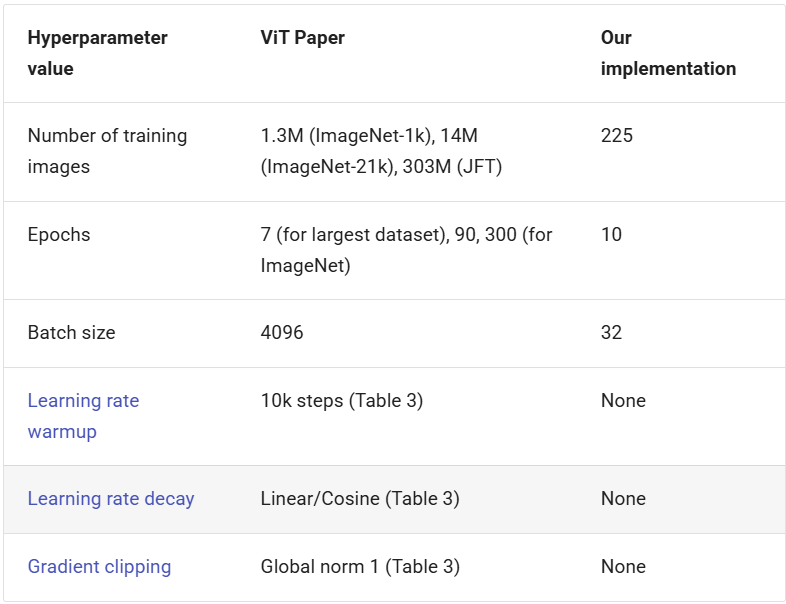

### 9.5 Plot the loss curves of our ViT model

In [ ]:
from helper_functions import plot_loss_curves

# Plot our ViT model's loss curves
plot_loss_curves(results)

## 10. Using a pretrained ViT from torchvision.models on the same dataset

Since we've now trained our own ViT from scratch and achieved less than optimal results, the benefits of transfer learning (using a pretrained model) really shine.

### 10.1 Why use a pretrained model?

An important note on many modern machine learning research papers is that much of the results are obtained with large datasets and vast compute resources.

And in modern day machine learning, the original fully trained ViT would likely not be considered a "super large" training setup (models are continually getting bigger and bigger).

### 10.2 Getting a pretrained ViT model and creating a feature extractor

In [ ]:
import torch
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # requires torchvision >= 0.13, "DEFAULT" means best available

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# 4. Change the classifier head (set the seeds to ensure same initialization with linear head)
set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)
pretrained_vit

### 10.3 Preparing data for the pretrained ViT model

When using a pretrained model, you want to format your data the same way your model was trained on.

In [ ]:
from helper_functions import download_data

# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

In [ ]:
# Setup train and test directory paths
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

In [ ]:
# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

In [ ]:
# Setup dataloaders
train_dataloader_pretrained, test_dataloader_pretrained, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     transform=pretrained_vit_transforms,
                                                                                                     batch_size=32) # Could increase if we had more samples, such as here: https://arxiv.org/abs/2205.01580 (there are other improvements there too...)


### 10.4 Train feature extractor ViT model

In [ ]:
from going_modular.going_modular import engine

# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT feature extractor model
set_seeds()
pretrained_vit_results = engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_pretrained,
                                      test_dataloader=test_dataloader_pretrained,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=10,
                                      device=device)

### 10.5 Plot feature extractor ViT model loss curves

In [ ]:
from helper_functions import plot_loss_curves

# Plot the loss curves
plot_loss_curves(pretrained_vit_results)

### 10.6 Save feature extractor ViT model and check file size

In [ ]:
# Save the model
from going_modular.going_modular import utils

utils.save_model(model=pretrained_vit,
                 target_dir="models",
                 model_name="08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth")

In [ ]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

## 11. Make predictions on a custom image

In [ ]:
import requests

# Import function to make predictions on images and plot them
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = image_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)